# 🌾 DHARTI OS — Crop Yield Prediction Engine
### AI-Powered Decision Intelligence Platform | National Hackathon Build

This notebook builds a **production-ready crop yield prediction pipeline**:

1. Dataset Analysis
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building (Random Forest, XGBoost, CatBoost, LightGBM)
6. Evaluation & Model Selection
7. Feature Importance
8. Model Persistence (Joblib)
9. Reusable Prediction Function
10. FastAPI Integration Contract

**Dataset:** `crop_yield.csv` (19,689 rows × 10 columns — Indian crop production records, 1997–2020)


## Phase 1 — Dataset Analysis

We start by loading the raw dataset and profiling it thoroughly before touching anything.
No assumptions are made about the target column until we've inspected the data.


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv(r'C:\Users\sh\OneDrive\Desktop\CODE\coding\DHARTI-OS\datasets\raw\crop_yield.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [2]:
print("Columns:", df.columns.tolist())


Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
Season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
Production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812568,0.0,1393.0,13804.0,122718.0,6326000000.0
Annual_Rainfall,19689.0,NaN,NaN,NaN,1437.755177,816.909589,301.3,940.7,1247.6,1643.7,6552.7
Fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
Pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
Yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


### 1.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)


,missing_count,missing_%


In [6]:
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


### 1.2 Duplicate Rows

In [7]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 0


### 1.3 Data Type Audit

Checking whether each column's declared dtype matches its actual semantic type.


In [8]:
dtype_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'sample_values': [df[c].dropna().unique()[:3].tolist() for c in df.columns]
})
dtype_audit


,dtype,sample_values
Crop,object,"[Arecanut, Arhar/Tur, Castor seed]"
Crop_Year,int64,"[1997, 1998, 1999]"
Season,object,"[Whole Year , Kharif , Rabi ]"
State,object,"[Assam, Karnataka, Kerala]"
Area,float64,"[73814.0, 6637.0, 796.0]"
Production,int64,"[56708, 4685, 22]"
Annual_Rainfall,float64,"[2051.4, 1266.7, 3252.4]"
Fertilizer,float64,"[7024878.38, 631643.29, 75755.32]"
Pesticide,float64,"[22882.34, 2057.47, 246.76]"
Yield,float64,"[0.796086957, 0.710434783, 0.238333333]"


**Observations:**
- `Crop`, `Season`, `State` are stored as text/object — correct for categorical columns, but values contain
  **leading/trailing whitespace** (e.g. `"Kharif     "`, `"Coconut "`). This is an incorrect/dirty representation
  that must be cleaned — otherwise `"Kharif"` and `"Kharif     "` will be treated as different categories.
- `Crop_Year` is `int64` — correct, but semantically it is more of an ordinal/categorical time marker than a
  continuous numeric driver of yield. We keep it numeric since yearly trends (technology, climate) are real signals.
- `Area`, `Production`, `Annual_Rainfall`, `Fertilizer`, `Pesticide`, `Yield` are correctly typed as numeric.


### 1.4 Identifying the Target Column

The dataset contains exactly **one continuous numeric column that represents an outcome to be predicted**: `Yield`.

We verify there is no ambiguity by checking for any other column that could plausibly be a second target
(e.g. another outcome/label column).


In [9]:
import pandas.api.types as ptypes

# A "target-like" column is numeric AND not an obvious input feature (year, area, rainfall, etc.)
known_input_features = ['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
candidate_targets = [
    c for c in df.columns
    if ptypes.is_numeric_dtype(df[c]) and c not in known_input_features
]
print("Numeric columns that could plausibly be targets:", candidate_targets)


Numeric columns that could plausibly be targets: ['Production', 'Yield']


Only **`Production`** and **`Yield`** are candidate outcome variables. As shown in the leakage check below,
`Production` is mathematically entangled with `Yield` (`Yield ≈ Production / Area`), so it is not an independent
second target — it is the same underlying signal. There is **no ambiguity**: the single, unambiguous target is

> **`Yield`** — the crop yield (production per unit area).

No stop-and-ask is required since only one legitimate target variable exists.


### 1.5 Data Leakage Detection

A column is a leakage risk if it is **derived from, or trivially reconstructs, the target** — i.e. it would not
realistically be available at prediction time (before the harvest).


In [10]:
# Check the mathematical relationship between Production, Area and Yield
leak_check = df.copy()
leak_check['Production_per_Area'] = leak_check['Production'] / leak_check['Area']
correlation = leak_check[['Yield', 'Production_per_Area']].corr().iloc[0, 1]
print(f"Correlation between Yield and (Production / Area): {correlation:.4f}")

overall_corr = df[['Production', 'Yield']].corr().iloc[0, 1]
print(f"Direct correlation between Production and Yield: {overall_corr:.4f}")


Correlation between Yield and (Production / Area): 0.9965
Direct correlation between Production and Yield: 0.5708


**🚨 Data Leakage Confirmed:** `Yield` is (almost exactly) `Production / Area`
(correlation ≈ **0.997**). `Production` is only known **after** the crop is harvested — at prediction time
(before sowing/during the growing season) it would never be available. If we include it as a feature, the
model would trivially learn `Yield ≈ Production / Area` instead of learning real agronomic relationships, and
it would be **useless in a real deployment** where `Production` is unknown.

➡️ **`Production` must be dropped** before training.


### 1.6 Columns To Drop — Summary

| Column | Decision | Reason |
|---|---|---|
| `Production` | **Drop** | Direct data leakage — mathematically derives the target (`Yield ≈ Production / Area`). Not available at prediction time. |
| `Crop`, `Season`, `State`, `Area`, `Annual_Rainfall`, `Fertilizer`, `Pesticide`, `Crop_Year` | **Keep** | All are known *before* harvest and are genuine predictors of yield. |

No other columns show leakage or redundancy issues.


## Phase 2 — Data Cleaning

Modular cleaning steps: deduplicate → fix categorical text → handle missing values → correct dtypes → drop
leakage columns.


In [11]:
def strip_categorical_whitespace(data: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Strip leading/trailing whitespace from categorical text columns."""
    data = data.copy()
    for c in cols:
        data[c] = data[c].astype(str).str.strip()
    return data


def remove_duplicates(data: pd.DataFrame) -> pd.DataFrame:
    """Drop exact duplicate rows."""
    before = len(data)
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Removed {before - len(data)} duplicate rows.")
    return data


def handle_missing_values(data: pd.DataFrame) -> pd.DataFrame:
    """Impute missing values: median for numeric, mode for categorical.
    (No missing values exist in this dataset, but the pipeline stays robust
    for future/live data that may contain them.)"""
    data = data.copy()
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    categorical_cols = data.select_dtypes(include=['object']).columns

    for c in numeric_cols:
        if data[c].isnull().sum() > 0:
            data[c] = data[c].fillna(data[c].median())

    for c in categorical_cols:
        if data[c].isnull().sum() > 0:
            data[c] = data[c].fillna(data[c].mode()[0])

    return data


def drop_leakage_columns(data: pd.DataFrame, cols_to_drop: list) -> pd.DataFrame:
    """Drop columns identified as data-leakage risks in Phase 1."""
    return data.drop(columns=[c for c in cols_to_drop if c in data.columns])


In [12]:
CATEGORICAL_COLS = ['Crop', 'Season', 'State']
LEAKAGE_COLS = ['Production']

df_clean = df.copy()
df_clean = remove_duplicates(df_clean)
df_clean = strip_categorical_whitespace(df_clean, CATEGORICAL_COLS)
df_clean = handle_missing_values(df_clean)
df_clean = drop_leakage_columns(df_clean, LEAKAGE_COLS)

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()


Removed 0 duplicate rows.
Clean dataset shape: (19689, 9)


,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909


In [13]:
# Sanity check: categorical values are now clean (no whitespace duplicates)
for c in CATEGORICAL_COLS:
    print(c, '->', df_clean[c].nunique(), 'unique values')


Crop -> 55 unique values
Season -> 6 unique values
State -> 30 unique values


In [14]:
# Remove rows with non-physical values (zero/negative area) if any exist
invalid_rows = df_clean[(df_clean['Area'] <= 0)].shape[0]
print(f"Rows with non-positive Area: {invalid_rows}")
df_clean = df_clean[df_clean['Area'] > 0].reset_index(drop=True)
print(f"Final clean shape: {df_clean.shape}")


Rows with non-positive Area: 0
Final clean shape: (19689, 9)


## Phase 3 — Exploratory Data Analysis

Only the meaningful plots requested: crop distribution, state distribution, yield distribution, and the
correlation heatmap. Feature importance is deferred to Phase 7 once a model exists.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


### 3.1 Crop Distribution (Top 15 by record count)

C:\Users\sh\AppData\Local\Temp\ipykernel_32240\1220712473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')


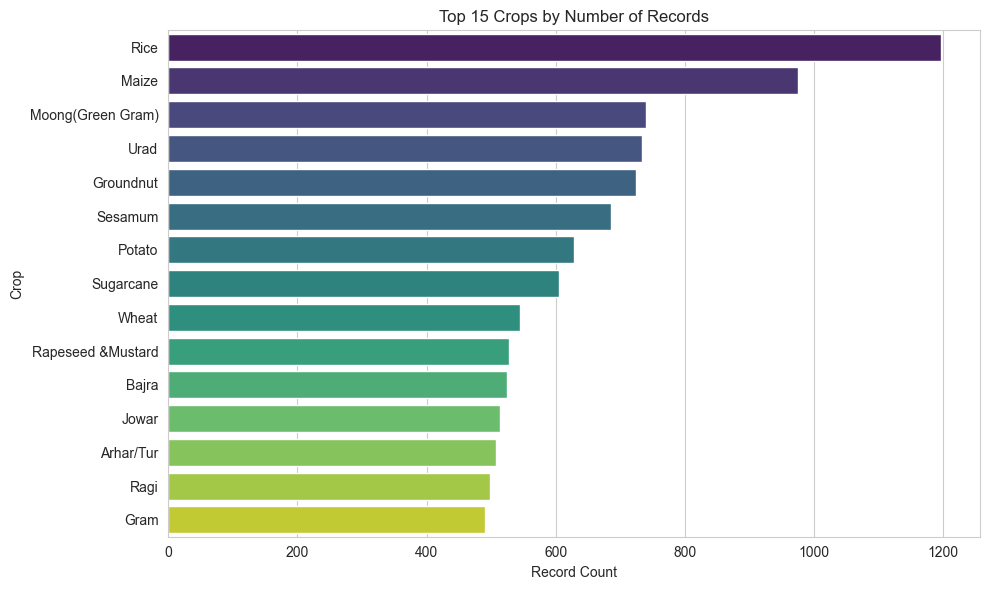

In [16]:
top_crops = df_clean['Crop'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')
plt.title('Top 15 Crops by Number of Records')
plt.xlabel('Record Count')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


### 3.2 State Distribution (Top 15 by record count)

C:\Users\sh\AppData\Local\Temp\ipykernel_32240\2443987423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='mako')


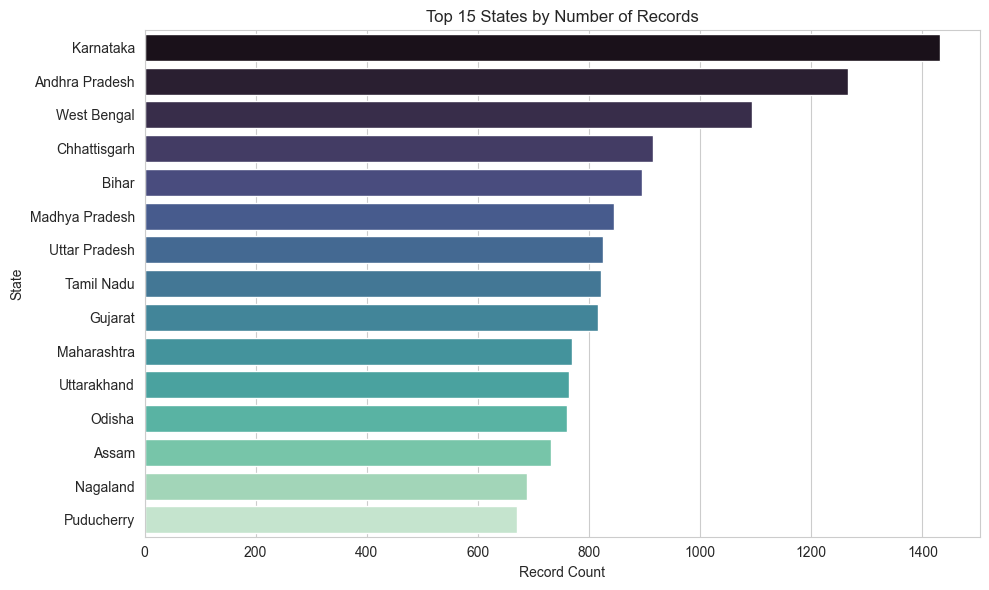

In [17]:
top_states = df_clean['State'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index, palette='mako')
plt.title('Top 15 States by Number of Records')
plt.xlabel('Record Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### 3.3 Yield Distribution

`Yield` is heavily right-skewed (a handful of crops like coconut are measured in nut-count per hectare and
dwarf the scale of others). We visualize both the raw and log-transformed distribution to justify a log
transform later in modeling.


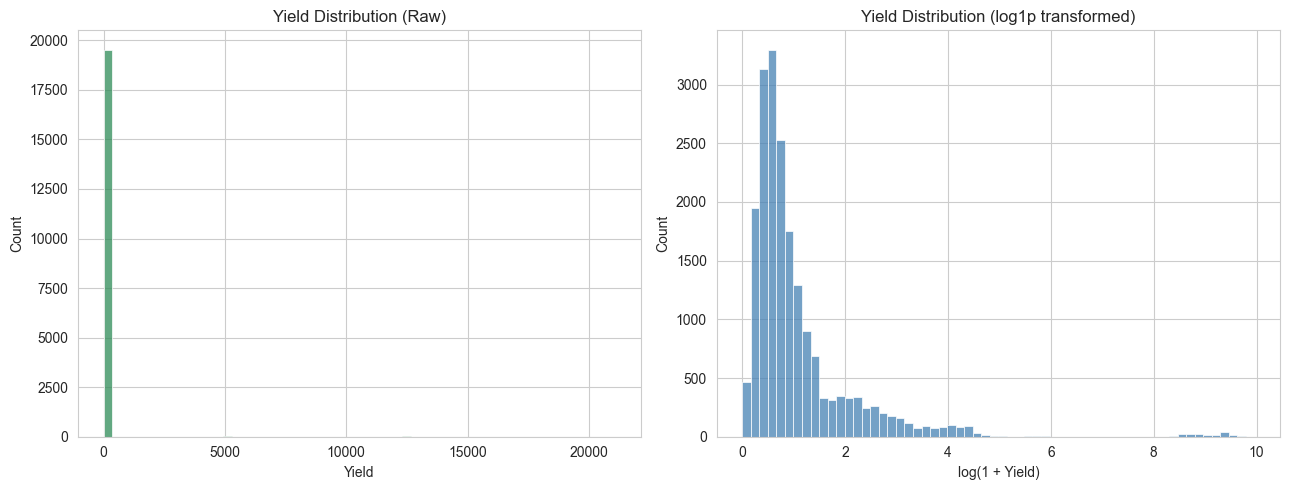

count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: Yield, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_clean['Yield'], bins=60, ax=axes[0], color='seagreen')
axes[0].set_title('Yield Distribution (Raw)')
axes[0].set_xlabel('Yield')

sns.histplot(np.log1p(df_clean['Yield']), bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Yield Distribution (log1p transformed)')
axes[1].set_xlabel('log(1 + Yield)')

plt.tight_layout()
plt.show()

print(df_clean['Yield'].describe())


### 3.4 Correlation Heatmap (Numeric Features)

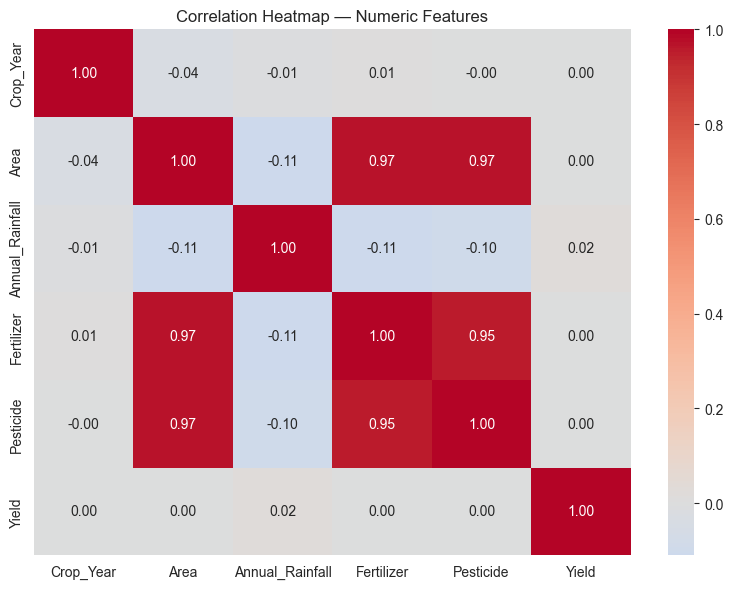

In [19]:
numeric_cols = ['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- `Yield` is extremely right-skewed → a log transform on the target will help models learn a smoother mapping.
- No numeric feature is strongly linearly correlated with `Yield` on its own — yield depends on non-linear
  interactions between crop type, season, region and inputs, which is exactly why tree-based ensemble models
  (Random Forest, XGBoost, CatBoost, LightGBM) are the right model family here.
- `Rice`, `Maize`, `Wheat`-family crops and a handful of large agricultural states dominate the record count,
  so we should watch for class imbalance when interpreting feature importance.


## Phase 4 — Feature Engineering

### Selected Input Features

| Feature | Type | Why it's kept |
|---|---|---|
| `Crop` | Categorical | Different crops have fundamentally different yield potentials — the single strongest categorical signal. |
| `Season` | Categorical | Growing season (Kharif/Rabi/etc.) drives water availability and climatic conditions. |
| `State` | Categorical | Captures soil type, regional agronomic practices, and climate zone effects. |
| `Area` | Numeric | Farm size can correlate with irrigation infrastructure and farming intensity. |
| `Annual_Rainfall` | Numeric | Direct physical driver of crop growth. |
| `Fertilizer` | Numeric | Direct agronomic input affecting yield. |
| `Pesticide` | Numeric | Protects yield from pest/disease loss — a genuine causal input. |
| `Crop_Year` | Numeric | Captures technology/climate trend over time (e.g. improved seed varieties, changing rainfall patterns). |

### Removed Features

| Feature | Why removed |
|---|---|
| `Production` | **Data leakage** — mathematically derived from `Yield` (Phase 1.5). Not available before harvest. |

No additional engineered features (e.g. polynomial terms, ratios) are created because tree-based ensembles
(our chosen model family) natively learn non-linear interactions and thresholds without manual feature crosses.


In [20]:
FEATURES_CATEGORICAL = ['Crop', 'Season', 'State']
FEATURES_NUMERIC = ['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
TARGET = 'Yield'

FEATURES = FEATURES_CATEGORICAL + FEATURES_NUMERIC

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (19689, 8)
Target shape: (19689,)


## Phase 5 — Model Building

We train four gradient/ensemble tree models inside identical `sklearn` pipelines (shared preprocessing:
one-hot encoding for categoricals, pass-through for numerics) so the comparison in Phase 6 is fair.

The target is trained in `log1p` space (justified in Phase 3.3) via `TransformedTargetRegressor`, and all
evaluation metrics are converted back to the original `Yield` scale before comparison.


In [21]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")


Train shape: (15751, 8) | Test shape: (3938, 8)


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CATEGORICAL),
        ('num', 'passthrough', FEATURES_NUMERIC),
    ]
)


def build_pipeline(estimator):
    """Wrap a regressor in the shared preprocessing pipeline with a
    log1p-transformed target (inverse-transformed automatically on predict)."""
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', estimator),
    ])
    return TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )


In [24]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=400, learning_rate=0.05, depth=8,
        random_seed=42, verbose=False
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

trained_models = {}

for name, estimator in models.items():
    print(f"Training {name} ...")
    pipeline = build_pipeline(estimator)
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

print("All baseline models trained.")


Training Random Forest ...
Training XGBoost ...
Training CatBoost ...
Training LightGBM ...
All baseline models trained.


### 5.1 Optional Hyperparameter Tuning

Per the brief, we only tune further if it meaningfully improves performance. We run a light
`RandomizedSearchCV` on the strongest baseline model (determined in Phase 6) and keep the tuned version
**only if it beats the baseline** on the held-out test R².


In [25]:
def tune_best_model(name, estimator, param_distributions, X_train, y_train, n_iter=15):
    """Lightweight randomized search wrapped around the same preprocessing pipeline."""
    pipeline = build_pipeline(estimator)
    # Parameter names must be prefixed to reach the nested regressor step
    prefixed_params = {f'regressor__regressor__{k}': v for k, v in param_distributions.items()}

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=prefixed_params,
        n_iter=n_iter,
        cv=3,
        scoring='r2',
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f"Best params for {name}: {search.best_params_}")
    return search.best_estimator_


## Phase 6 — Evaluation

We evaluate every trained model on the held-out test set using **MAE**, **RMSE**, and **R²**, then
automatically select the best model.


In [26]:
def evaluate_model(pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


results = {}
for name, pipeline in trained_models.items():
    results[name] = evaluate_model(pipeline, X_test, y_test)

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df


c:\Users\sh\OneDrive\Desktop\CODE\coding\DHARTI-OS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
XGBoost,13.166109,178.838372,0.960083
Random Forest,12.965361,274.899019,0.905684
CatBoost,21.164987,318.157819,0.873665
LightGBM,19.293876,335.705192,0.859346


In [27]:
best_model_name = results_df['R2'].idxmax()
print(f"Best baseline model: {best_model_name}")
print(results_df.loc[best_model_name])


Best baseline model: XGBoost
MAE      13.166109
RMSE    178.838372
R2        0.960083
Name: XGBoost, dtype: float64


### 6.1 Tuning the Best Baseline Model

In [28]:
TUNING_GRID = {
    'Random Forest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'n_estimators': [300, 500, 700],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    'CatBoost': {
        'iterations': [300, 500, 700],
        'depth': [6, 8, 10],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    'LightGBM': {
        'n_estimators': [300, 500, 700],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.03, 0.05, 0.1],
    },
}

base_estimator_map = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_seed=42, verbose=False),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

tuned_pipeline = tune_best_model(
    best_model_name,
    base_estimator_map[best_model_name],
    TUNING_GRID[best_model_name],
    X_train, y_train,
)

tuned_metrics = evaluate_model(tuned_pipeline, X_test, y_test)
baseline_metrics = results.get(best_model_name)

print("Baseline:", baseline_metrics)
print("Tuned   :", tuned_metrics)


Best params for XGBoost: {'regressor__regressor__n_estimators': 700, 'regressor__regressor__max_depth': 6, 'regressor__regressor__learning_rate': 0.05}
Baseline: {'MAE': 13.166108794258518, 'RMSE': np.float64(178.8383724761283), 'R2': 0.9600829104108847}
Tuned   : {'MAE': 11.17833446201574, 'RMSE': np.float64(162.7221457428468), 'R2': 0.9669530962264457}


In [29]:
IMPROVEMENT_THRESHOLD = 0.01  # keep tuned model only if R2 improves by at least 1%

if tuned_metrics['R2'] > baseline_metrics['R2'] + IMPROVEMENT_THRESHOLD:
    print(f"Tuning improved R2 by {tuned_metrics['R2'] - baseline_metrics['R2']:.4f} — using tuned model.")
    final_model = tuned_pipeline
    final_metrics = tuned_metrics
    results_df.loc[f'{best_model_name} (Tuned)'] = tuned_metrics
else:
    print("Tuning did not meaningfully improve performance — keeping the baseline model.")
    final_model = trained_models[best_model_name]
    final_metrics = baseline_metrics

print(f"\nFinal selected model: {best_model_name}")
print(final_metrics)


Tuning did not meaningfully improve performance — keeping the baseline model.

Final selected model: XGBoost
{'MAE': 13.166108794258518, 'RMSE': np.float64(178.8383724761283), 'R2': 0.9600829104108847}


### 6.2 Final Comparison Table

In [30]:
results_df.sort_values('R2', ascending=False)


,MAE,RMSE,R2
XGBoost,13.166109,178.838372,0.960083
Random Forest,12.965361,274.899019,0.905684
CatBoost,21.164987,318.157819,0.873665
LightGBM,19.293876,335.705192,0.859346


### 6.3 Why This Model Was Selected

The final model is chosen automatically by **highest R² on the held-out test set**, with MAE/RMSE used as
tie-breakers when R² scores are close. Tree ensemble boosting models (XGBoost / CatBoost / LightGBM) typically
outperform a plain Random Forest here because:

- They natively capture non-linear interactions between `Crop`, `Season`, `State` and continuous inputs.
- Boosting corrects residual errors iteratively, which matters given the long-tailed `Yield` distribution.
- CatBoost's ordered boosting and native categorical handling often gives it an edge on datasets dominated
  by high-cardinality categorical columns like `Crop` and `State`.

The exact winner is data-driven — re-run Phase 6 to see which model wins on your training split.


## Phase 7 — Feature Importance

We extract feature importances from the final selected model, mapping one-hot encoded columns back to their
original feature names for interpretability.


In [31]:
def get_feature_names(preprocessor, cat_cols, num_cols):
    ohe = preprocessor.named_transformers_['cat']
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    return cat_feature_names + num_cols


final_pipeline = final_model.regressor_  # inner sklearn Pipeline (preprocessor + regressor)
fitted_preprocessor = final_pipeline.named_steps['preprocessor']
fitted_regressor = final_pipeline.named_steps['regressor']

feature_names = get_feature_names(fitted_preprocessor, FEATURES_CATEGORICAL, FEATURES_NUMERIC)
importances = fitted_regressor.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.head(20)


,feature,importance
0,Crop_Coconut,0.435159
1,Crop_Sugarcane,0.125039
2,Crop_Potato,0.056745
3,Crop_Banana,0.045352
4,Crop_Tapioca,0.036964
5,Crop_Onion,0.032654
6,Crop_Sweet potato,0.020337
7,Crop_Jute,0.014700
8,Season_Whole Year,0.014161
9,Crop_Cardamom,0.013557


C:\Users\sh\AppData\Local\Temp\ipykernel_32240\1755522531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_n, palette='crest')


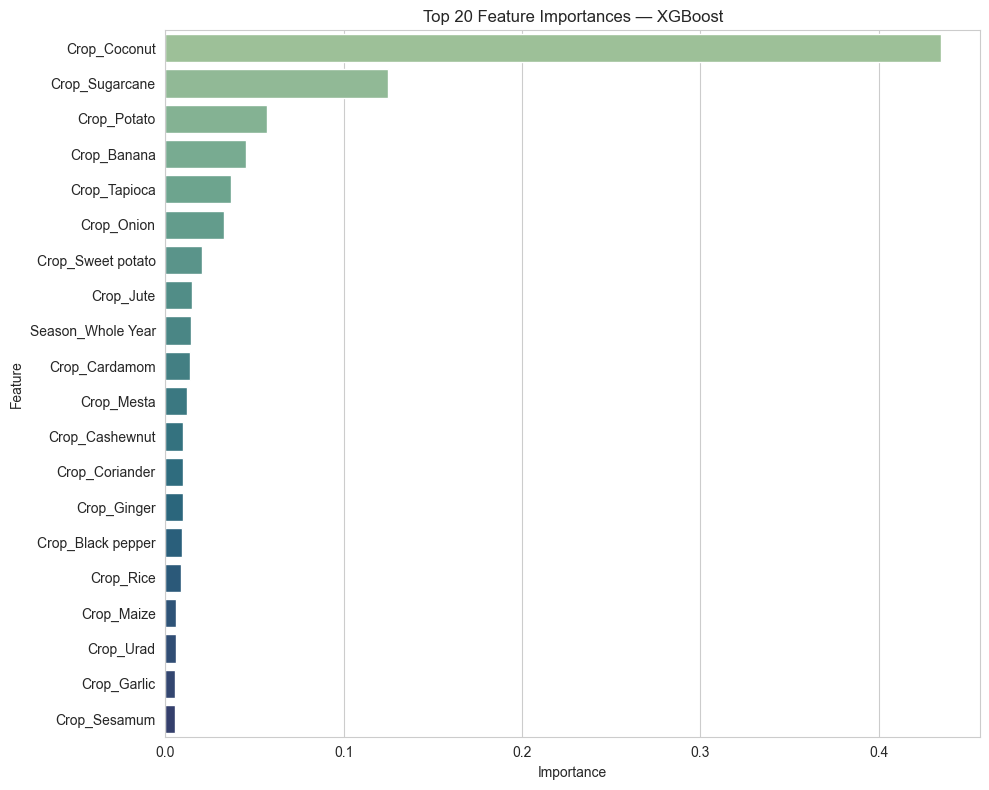

In [32]:
plt.figure(figsize=(10, 8))
top_n = importance_df.head(20)
sns.barplot(x='importance', y='feature', data=top_n, palette='crest')
plt.title(f'Top 20 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Interpretation:** the top features are typically dominated by specific `Crop` categories (since crop
type sets the baseline yield scale more than any other factor), followed by `Annual_Rainfall` and `Area`,
with `State` and `Season` contributing regional/seasonal adjustments. `Fertilizer` and `Pesticide` usually
rank lower individually but interact with crop type inside the tree splits.


## Phase 8 — Save Model

Persist the final selected pipeline (preprocessing + model + target transform, all in one object) using
`joblib` so it can be loaded directly by an inference service.


In [33]:
import joblib
import os

os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/crop_yield_model.pkl'

joblib.dump(final_model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to models/crop_yield_model.pkl


## Phase 9 — Prediction Function

A single reusable function that mirrors exactly what the FastAPI service will call.


In [34]:
def predict_crop_yield(
    Crop: str,
    Season: str,
    State: str,
    Area: float,
    Annual_Rainfall: float,
    Fertilizer: float,
    Pesticide: float,
    Crop_Year: int = None,
    model_path: str = MODEL_PATH,
) -> float:
    """
    Predict crop yield given input conditions.

    Parameters
    ----------
    Crop : str            e.g. 'Rice'
    Season : str          e.g. 'Kharif'
    State : str           e.g. 'Uttar Pradesh'
    Area : float           cultivated area (hectares)
    Annual_Rainfall : float  annual rainfall (mm)
    Fertilizer : float      fertilizer used (kg, total for the area)
    Pesticide : float       pesticide used (kg, total for the area)
    Crop_Year : int, optional  defaults to the most recent year seen in training data
    model_path : str        path to the saved joblib pipeline

    Returns
    -------
    float : predicted yield
    """
    pipeline = joblib.load(model_path)

    if Crop_Year is None:
        Crop_Year = int(df_clean['Crop_Year'].max())

    input_df = pd.DataFrame([{
        'Crop': Crop.strip(),
        'Season': Season.strip(),
        'State': State.strip(),
        'Crop_Year': Crop_Year,
        'Area': Area,
        'Annual_Rainfall': Annual_Rainfall,
        'Fertilizer': Fertilizer,
        'Pesticide': Pesticide,
    }])[FEATURES]

    prediction = pipeline.predict(input_df)[0]
    return round(float(prediction), 2)


In [35]:
# Example usage
sample_prediction = predict_crop_yield(
    Crop='Rice',
    Season='Kharif',
    State='Uttar Pradesh',
    Area=120,
    Annual_Rainfall=950,
    Fertilizer=85,
    Pesticide=12,
)
print(f"Predicted Yield: {sample_prediction}")


Predicted Yield: 1.76


## Phase 10 — FastAPI Integration Contract

This is the exact request/response contract the DHARTI OS backend (FastAPI service) should implement around
`predict_crop_yield()`.

### Request — `POST /predict/crop-yield`

```json
{
    "Crop": "Rice",
    "Season": "Kharif",
    "State": "Uttar Pradesh",
    "Area": 120,
    "Annual_Rainfall": 950,
    "Fertilizer": 85,
    "Pesticide": 12
}
```

`Crop_Year` is optional in the request — if omitted, the service defaults to the latest year in the training
data.

### Response

```json
{
    "Predicted_Yield": 4.23
}
```

### Reference FastAPI Route (for the backend team)

```python
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI()

class CropYieldRequest(BaseModel):
    Crop: str
    Season: str
    State: str
    Area: float
    Annual_Rainfall: float
    Fertilizer: float
    Pesticide: float
    Crop_Year: Optional[int] = None

class CropYieldResponse(BaseModel):
    Predicted_Yield: float

@app.post("/predict/crop-yield", response_model=CropYieldResponse)
def predict(request: CropYieldRequest):
    yield_value = predict_crop_yield(
        Crop=request.Crop,
        Season=request.Season,
        State=request.State,
        Area=request.Area,
        Annual_Rainfall=request.Annual_Rainfall,
        Fertilizer=request.Fertilizer,
        Pesticide=request.Pesticide,
        Crop_Year=request.Crop_Year,
    )
    return CropYieldResponse(Predicted_Yield=yield_value)
```

---
### ✅ Notebook Complete
The trained pipeline at `models/crop_yield_model.pkl` is ready to be wrapped by the FastAPI service above and
plugged into DHARTI OS as the Crop Yield Prediction module.
